# Urban Feature Extraction — Vashi Sentinel-2 (Fixed Pipeline)

### Bugs fixed vs original notebook
| # | Bug | Fix |
|---|-----|-----|
| 1 | `np.clip(0,1)` left 50% of dynamic range unused | Per-band 2–98% percentile stretch |
| 2 | Augmented patches mixed with originals before random split — train/val contamination | Spatial split first, augment training region only |
| 3 | PatchCNN printed training accuracy only (no val) | Val accuracy reported every epoch |
| 4 | PatchCNN had no BatchNorm / Dropout | Added both |
| 5 | Mask R-CNN evaluated on its own training loader (fake 100% recall) | Separate val loader for evaluation |
| 6 | Mask R-CNN silently capped instances per patch at 3 (`masks[:3]`) | Removed cap, all instances used |
| 7 | No LR scheduler on any model | `ReduceLROnPlateau` added |
| 8 | No best-model checkpointing | Save whenever val_loss / val_acc improves |
| 9 | No `torch.save()` anywhere — weights lost after session | All 3 models saved to `models/` |
| 10 | No full-image inference | U-Net runs on entire image, saves GeoTIFF + area stats |

In [1]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import torch
import torch.nn as nn
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

IMAGE_PATH = 'data/images/Vashi_Sentinel2_Input.tif'
MASK_PATH  = 'data/masks/Vashi_LabelMask_6Classes.tif'
os.makedirs('models', exist_ok=True)

NUM_CLASSES  = 7
IGNORE_LABEL = 0
CLASS_NAMES  = ['Ignore', 'Water', 'Buildings', 'Roads', 'Vegetation', 'Open Ground', 'Other Land']
CLASS_COLORS = ['black', 'deepskyblue', 'red', 'gray', 'green', 'yellow', 'orange']

Device: cuda


In [2]:
with rasterio.open(IMAGE_PATH) as src:
    image   = src.read().astype(np.float32)   # (C, H, W)
    profile = src.profile

with rasterio.open(MASK_PATH) as src:
    mask = src.read(1).astype(np.int64)        # (H, W)

print('Image shape (C, H, W):', image.shape)
print('Mask  shape    (H, W):', mask.shape)
print('Image raw range       :', image.min(), '-', image.max())
print('Unique mask values    :', np.unique(mask))

Image shape (C, H, W): (4, 385, 489)
Mask  shape    (H, W): (385, 489)
Image raw range       : nan - nan
Unique mask values    : [0 1 2 3 4 5 6]


## FIX 1 — Per-band 2–98% percentile normalization
Original code used `np.clip(image, 0, 1)` which left the range `[0.49, 1.0]` completely empty.
Per-band percentile stretch ensures each band uses the full `[0, 1]` range.

In [3]:
image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)

valid_mask = mask > IGNORE_LABEL   # only labeled pixels for percentile stats
norm_stats = {}                    # stored for inference-time use
image_norm = np.zeros_like(image)

for b in range(image.shape[0]):
    band      = image[b]
    valid_vals = band[valid_mask]
    p2, p98   = np.percentile(valid_vals, (2, 98))
    image_norm[b] = np.clip((band - p2) / (p98 - p2 + 1e-8), 0, 1)
    norm_stats[b] = {'p2': float(p2), 'p98': float(p98)}
    print(f'Band {b+1}: p2={p2:.5f}  p98={p98:.5f}  =>  '
          f'norm range [{image_norm[b].min():.3f}, {image_norm[b].max():.3f}]')

image = image_norm
print('\nNormalization done.')

Band 1: p2=0.00810  p98=0.11640  =>  norm range [0.000, 1.000]
Band 2: p2=0.02860  p98=0.14120  =>  norm range [0.000, 1.000]
Band 3: p2=0.02560  p98=0.17960  =>  norm range [0.000, 1.000]
Band 4: p2=0.03070  p98=0.25860  =>  norm range [0.000, 1.000]

Normalization done.


Class distribution:
  Class 0  Ignore      :  58616 px  (31.1%)
  Class 1  Water       :  17155 px  (9.1%)
  Class 2  Buildings   :  35854 px  (19.0%)
  Class 3  Roads       :  17813 px  (9.5%)
  Class 4  Vegetation  :  20485 px  (10.9%)
  Class 5  Open Ground :   4238 px  (2.3%)
  Class 6  Other Land  :  34104 px  (18.1%)


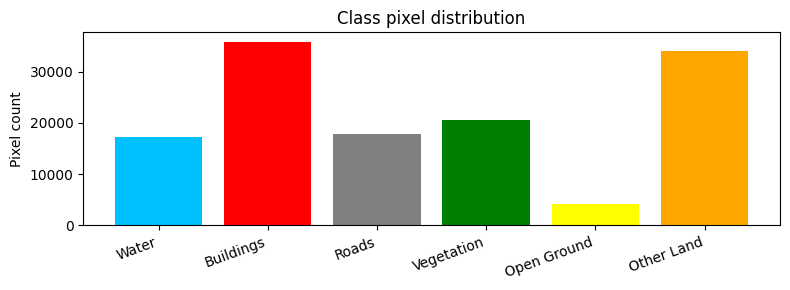

In [4]:
unique_labels, counts = np.unique(mask, return_counts=True)
print('Class distribution:')
for lbl, cnt in zip(unique_labels, counts):
    print(f'  Class {lbl}  {CLASS_NAMES[lbl]:12s}: {cnt:6d} px  ({100*cnt/mask.size:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar([CLASS_NAMES[l] for l in unique_labels[1:]], counts[1:],
       color=CLASS_COLORS[1:])
ax.set_title('Class pixel distribution'); ax.set_ylabel('Pixel count')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## FIX 2 — Spatial train / validation split
Original code: all patches extracted → randomly shuffled → split.  
**Problem**: An augmented copy of patch A (in train) and the original patch A (in val) are near-identical → the model memorises val.

**Fix**: reserve the bottom 30% of image rows as validation zone, extract patches from each zone independently, augment **only** training patches.

Image: 385 rows x 489 cols
Train zone : rows   0 – 268
Val   zone : rows 269 – 384


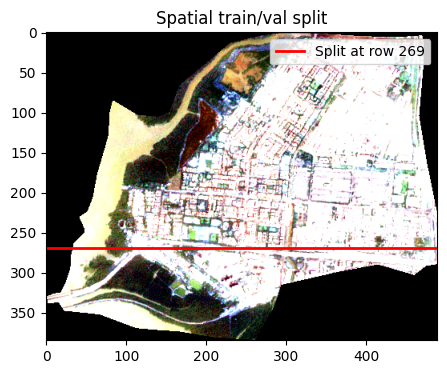

In [5]:
PATCH_SIZE    = 64
STRIDE        = 32
AUG_PER_PATCH = 4

C, H, W = image.shape
SPLIT_ROW = int(H * 0.70)

print(f'Image: {H} rows x {W} cols')
print(f'Train zone : rows   0 – {SPLIT_ROW-1}')
print(f'Val   zone : rows {SPLIT_ROW} – {H-1}')

# Visualise split
fig, ax = plt.subplots(figsize=(6, 4))
rgb = np.clip(image[:3].transpose(1, 2, 0) * 3.0, 0, 1)
ax.imshow(rgb)
ax.axhline(SPLIT_ROW, color='red', lw=2, label=f'Split at row {SPLIT_ROW}')
ax.legend(); ax.set_title('Spatial train/val split'); plt.show()

In [6]:
def augment_patch(img_p, msk_p):
    if random.random() > 0.5:
        img_p = np.flip(img_p, axis=2); msk_p = np.flip(msk_p, axis=1)
    if random.random() > 0.5:
        img_p = np.flip(img_p, axis=1); msk_p = np.flip(msk_p, axis=0)
    k = random.randint(0, 3)
    if k > 0:
        img_p = np.rot90(img_p, k, axes=(1, 2))
        msk_p = np.rot90(msk_p, k, axes=(0, 1))
    return img_p.copy(), msk_p.copy()


def extract_patches(img, msk, y_start, y_end, augment=False, aug_count=1):
    patches_img, patches_msk = [], []
    for y in range(y_start, y_end - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            ip = img[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            mp = msk[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            if np.all(mp == IGNORE_LABEL):
                continue
            patches_img.append(ip.copy())
            patches_msk.append(mp.copy())
            if augment:
                for _ in range(aug_count - 1):
                    ai, am = augment_patch(ip, mp)
                    patches_img.append(ai)
                    patches_msk.append(am)
    return np.array(patches_img), np.array(patches_msk)


train_imgs, train_msks = extract_patches(image, mask, 0, SPLIT_ROW,
                                          augment=True, aug_count=AUG_PER_PATCH)
val_imgs,   val_msks   = extract_patches(image, mask, SPLIT_ROW, H,
                                          augment=False)

print(f'Train patches : {len(train_imgs)}')
print(f'Val   patches : {len(val_imgs)}')
print(f'Train unique labels: {np.unique(train_msks)}')
print(f'Val   unique labels: {np.unique(val_msks)}')

Train patches : 364
Val   patches : 27
Train unique labels: [0 1 2 3 4 5 6]
Val   unique labels: [0 1 2 3 4 5 6]


In [7]:
class SentinelPatchDataset(Dataset):
    def __init__(self, imgs, msks):
        self.imgs = imgs
        self.msks = msks
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        return (torch.from_numpy(self.imgs[idx]).float(),
                torch.from_numpy(self.msks[idx]).long())


BATCH_SIZE = 8
train_ds = SentinelPatchDataset(train_imgs, train_msks)
val_ds   = SentinelPatchDataset(val_imgs,   val_msks)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 46  |  Val batches: 4


## Part A — U-Net Semantic Segmentation

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=7):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32,  64)
        self.enc3 = DoubleConv(64,  128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up4  = nn.ConvTranspose2d(512, 256, 2, 2); self.dec4 = DoubleConv(512, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, 2); self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  2, 2); self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64,  32,  2, 2); self.dec1 = DoubleConv(64,  32)
        self.out_conv = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out_conv(d1)


unet = UNet(in_channels=4, num_classes=NUM_CLASSES).to(device)
x_test = torch.randn(1, 4, 64, 64).to(device)
print('U-Net output shape:', unet(x_test).shape)
print('Parameters:', sum(p.numel() for p in unet.parameters() if p.requires_grad))

U-Net output shape: torch.Size([1, 7, 64, 64])
Parameters: 7766471


In [9]:
# FIX 7 — LR scheduler added
class_weights = torch.tensor([0.0, 1.5, 2.5, 4.0, 1.0, 1.5, 1.0], device=device)

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.softmax(pred, dim=1)
    loss = 0.0
    for cls in range(1, pred.shape[1]):
        p = pred[:, cls]
        t = (target == cls).float()
        loss += 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)
    return loss / (pred.shape[1] - 1)


ce_loss   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_LABEL)
unet_opt  = torch.optim.Adam(unet.parameters(), lr=4e-4)
unet_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    unet_opt, mode='min', factor=0.5, patience=5, verbose=True
)

In [10]:
# FIX 4 + FIX 8 — training with best-model checkpointing
# NOTE: on CPU expect ~45-90 min for 30 epochs. Increase EPOCHS for GPU.
EPOCHS = 30
best_val_loss = float('inf')
history = {'tl': [], 'vl': [], 'ta': [], 'va': []}

for epoch in range(EPOCHS):
    # ----- TRAIN -----
    unet.train()
    t_loss, t_cor, t_tot = 0.0, 0, 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        unet_opt.zero_grad()
        out  = unet(imgs)
        loss = ce_loss(out, msks) + 0.5 * dice_loss(out, msks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        unet_opt.step()
        t_loss += loss.item()
        with torch.no_grad():
            preds = torch.argmax(out, 1)
            valid = msks != IGNORE_LABEL
            t_cor += (preds[valid] == msks[valid]).sum().item()
            t_tot += valid.sum().item()

    # ----- VAL -----
    unet.eval()
    v_loss, v_cor, v_tot = 0.0, 0, 0
    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            out  = unet(imgs)
            loss = ce_loss(out, msks) + 0.5 * dice_loss(out, msks)
            v_loss += loss.item()
            preds  = torch.argmax(out, 1)
            valid  = msks != IGNORE_LABEL
            v_cor += (preds[valid] == msks[valid]).sum().item()
            v_tot += valid.sum().item()

    tl = t_loss / len(train_loader)
    vl = v_loss / len(val_loader)
    ta = t_cor / t_tot if t_tot > 0 else 0
    va = v_cor / v_tot if v_tot > 0 else 0

    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)

    unet_sched.step(vl)

    # FIX 8 — save best checkpoint
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(unet.state_dict(), 'models/unet_vashi_best.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS}] '
              f'Train Loss: {tl:.4f}  Acc: {ta:.4f} | '
              f'Val Loss: {vl:.4f}  Acc: {va:.4f}')

print(f'\nBest val loss: {best_val_loss:.4f}  saved -> models/unet_vashi_best.pth')

Epoch [ 1/30] Train Loss: 2.0836  Acc: 0.4385 | Val Loss: 2.2523  Acc: 0.5300
Epoch [ 5/30] Train Loss: 1.2182  Acc: 0.6429 | Val Loss: 1.7446  Acc: 0.5696
Epoch [10/30] Train Loss: 0.9565  Acc: 0.6980 | Val Loss: 2.0094  Acc: 0.5889
Epoch [15/30] Train Loss: 0.8218  Acc: 0.7402 | Val Loss: 1.8063  Acc: 0.6010
Epoch [20/30] Train Loss: 0.7241  Acc: 0.7752 | Val Loss: 1.7081  Acc: 0.6030
Epoch [25/30] Train Loss: 0.6659  Acc: 0.7979 | Val Loss: 1.9129  Acc: 0.6040
Epoch [30/30] Train Loss: 0.6247  Acc: 0.8117 | Val Loss: 2.0414  Acc: 0.5855

Best val loss: 1.6019  saved -> models/unet_vashi_best.pth


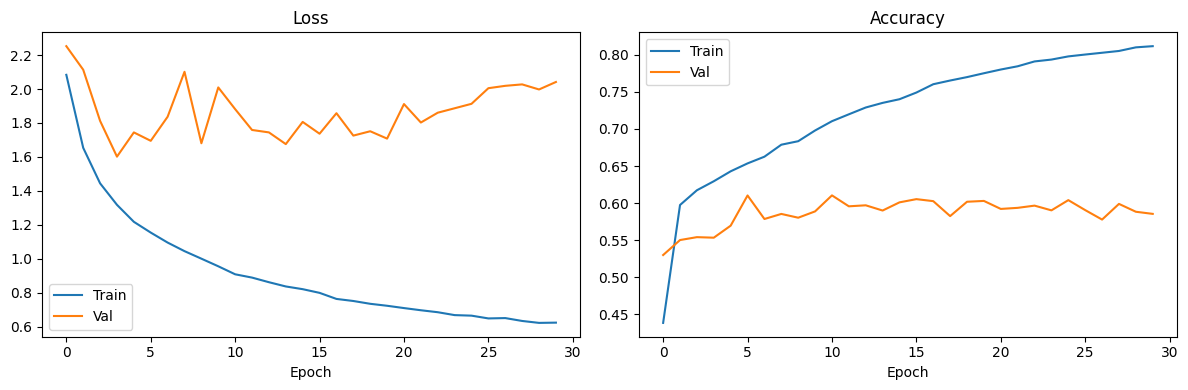

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['tl'], label='Train'); ax1.plot(history['vl'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['ta'], label='Train'); ax2.plot(history['va'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

       Water     0.6148    0.8893    0.7270      7732
   Buildings     0.3811    0.8896    0.5336     10018
       Roads     0.2772    0.4044    0.3289     12325
  Vegetation     0.9271    0.7921    0.8543     26120
 Open Ground     0.0335    0.0170    0.0225       412
  Other Land     0.5889    0.0641    0.1156     20728

    accuracy                         0.5534     77335
   macro avg     0.4704    0.5094    0.4303     77335
weighted avg     0.6262    0.5534    0.5138     77335

      Class    IoU   Dice
      Water 0.5711 0.7270
  Buildings 0.3638 0.5336
      Roads 0.1968 0.3289
 Vegetation 0.7456 0.8543
Open Ground 0.0114 0.0225
 Other Land 0.0613 0.1156

mIoU: 0.3250   mDice: 0.4303


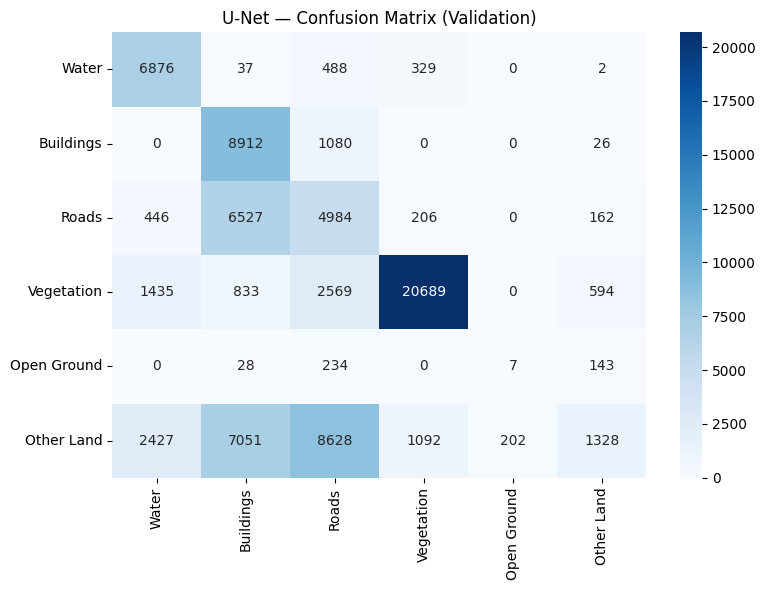

In [12]:
# Load best checkpoint for evaluation
unet.load_state_dict(torch.load('models/unet_vashi_best.pth', map_location=device))
unet.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, msks in val_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        preds = torch.argmax(unet(imgs), 1)
        valid = msks != IGNORE_LABEL
        all_preds.append(preds[valid].cpu().numpy())
        all_targets.append(msks[valid].cpu().numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

print(classification_report(
    all_targets, all_preds,
    labels=list(range(1, NUM_CLASSES)),
    target_names=CLASS_NAMES[1:],
    digits=4
))

# Per-class IoU + Dice
rows = []
for cls in range(1, NUM_CLASSES):
    pc = all_preds == cls; tc = all_targets == cls
    inter = np.logical_and(pc, tc).sum()
    union = np.logical_or(pc, tc).sum()
    iou  = inter / union if union > 0 else np.nan
    dice = 2*inter / (pc.sum() + tc.sum() + 1e-8)
    rows.append((CLASS_NAMES[cls], round(iou, 4), round(dice, 4)))

df_iou = pd.DataFrame(rows, columns=['Class', 'IoU', 'Dice'])
print(df_iou.to_string(index=False))
print(f'\nmIoU: {df_iou.IoU.mean():.4f}   mDice: {df_iou.Dice.mean():.4f}')

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=list(range(1, NUM_CLASSES)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES[1:], yticklabels=CLASS_NAMES[1:])
plt.title('U-Net — Confusion Matrix (Validation)'); plt.tight_layout(); plt.show()

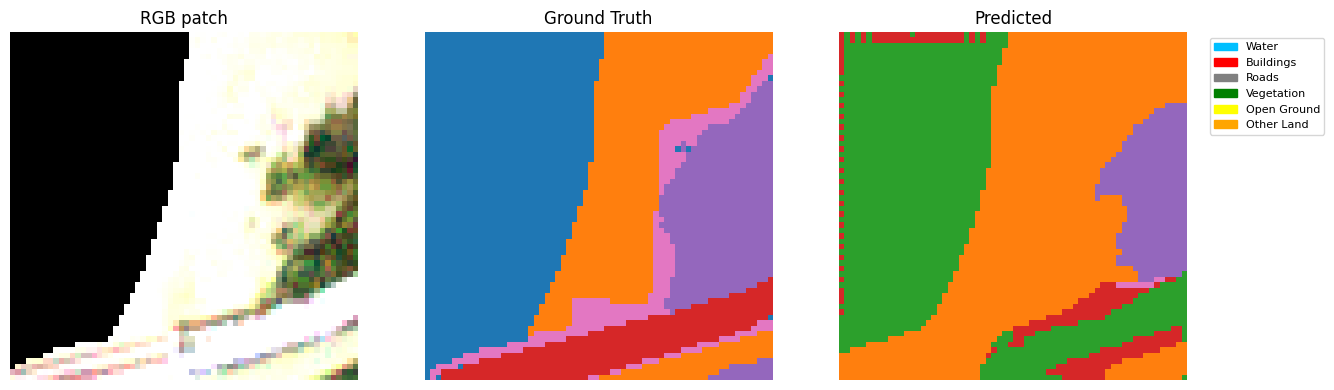

In [13]:
unet.eval()
with torch.no_grad():
    imgs, msks = next(iter(val_loader))
    preds = torch.argmax(unet(imgs.to(device)), 1).cpu()

idx = 0
rgb = np.clip(imgs[idx][:3].permute(1, 2, 0).numpy() * 3.0, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb);                     axes[0].set_title('RGB patch'); axes[0].axis('off')
axes[1].imshow(msks[idx],  cmap='tab10', vmin=0, vmax=9); axes[1].set_title('Ground Truth'); axes[1].axis('off')
axes[2].imshow(preds[idx], cmap='tab10', vmin=0, vmax=9); axes[2].set_title('Predicted');     axes[2].axis('off')

legend = [mpatches.Patch(color=c, label=n)
          for c, n in zip(CLASS_COLORS[1:], CLASS_NAMES[1:])]
plt.legend(handles=legend, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## FIX 10 — Full-image inference + area statistics
Original: only random patch predictions shown. 
Now: the full Vashi image is segmented and saved as a GeoTIFF.

Saved: models/unet_vashi_segmap.tif


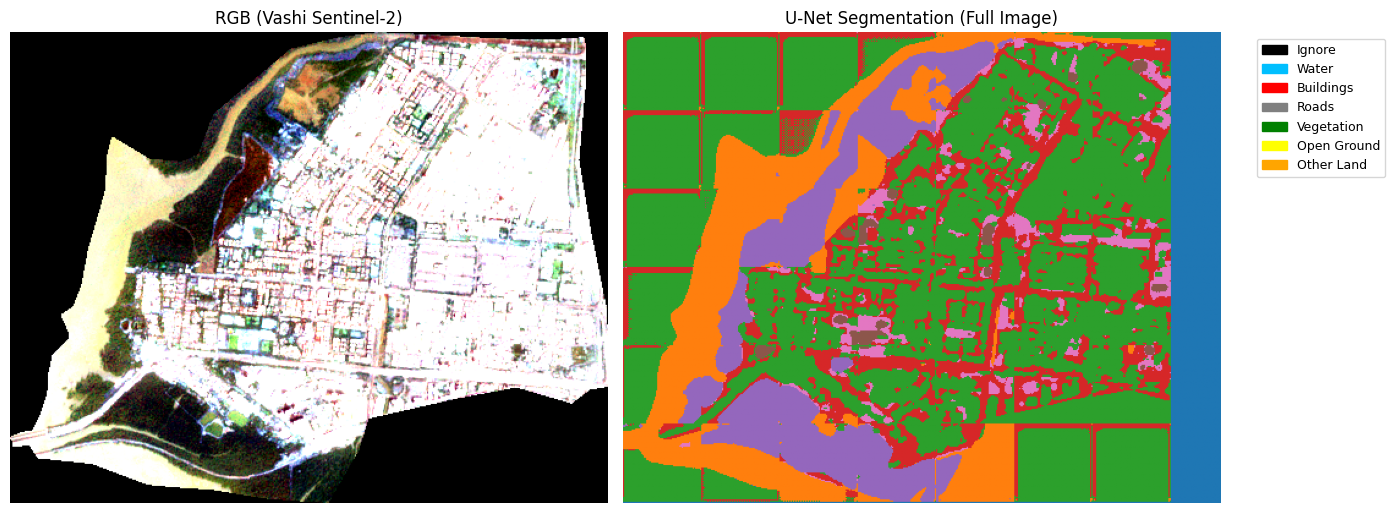

In [14]:
unet.eval()
pred_map = np.zeros((H, W), dtype=np.uint8)
conf_map = np.zeros((H, W), dtype=np.float32)

# Stride = PATCH_SIZE for non-overlapping tiles
with torch.no_grad():
    for y in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
            patch = torch.from_numpy(
                image[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            ).float().unsqueeze(0).to(device)
            out   = unet(patch)
            probs = torch.softmax(out, 1)
            pred  = torch.argmax(probs, 1).squeeze(0).cpu().numpy().astype(np.uint8)
            conf  = probs.max(1).values.squeeze(0).cpu().numpy()
            pred_map[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = pred
            conf_map[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = conf

# Save segmentation GeoTIFF
out_profile = profile.copy()
out_profile.update(count=1, dtype='uint8', nodata=0)
with rasterio.open('models/unet_vashi_segmap.tif', 'w', **out_profile) as dst:
    dst.write(pred_map[np.newaxis])
print('Saved: models/unet_vashi_segmap.tif')

# Visualise full-image result
rgb_full = np.clip(image[:3].transpose(1, 2, 0) * 3.0, 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(rgb_full);  axes[0].set_title('RGB (Vashi Sentinel-2)'); axes[0].axis('off')
axes[1].imshow(pred_map, cmap='tab10', vmin=0, vmax=9)
axes[1].set_title('U-Net Segmentation (Full Image)'); axes[1].axis('off')
legend = [mpatches.Patch(color=c, label=n)
          for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
axes[1].legend(handles=legend, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

Feature Area Statistics — U-Net prediction on full image
-------------------------------------------------------
  Water          :  19484 px    15.0%
  Buildings      :  51251 px    39.5%
  Roads          :  23589 px    18.2%
  Vegetation     :  19266 px    14.9%
  Open Ground    :   1474 px     1.1%
  Other Land     :   6336 px     4.9%


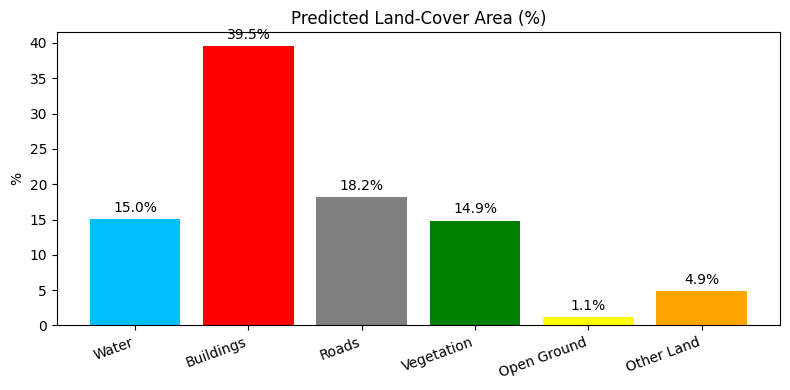

In [15]:
# Area statistics (only over labeled region)
labeled_preds = pred_map[mask > IGNORE_LABEL]
total_labeled = len(labeled_preds)

print('Feature Area Statistics — U-Net prediction on full image')
print('-' * 55)
for cls in range(1, NUM_CLASSES):
    cnt = (labeled_preds == cls).sum()
    pct = 100 * cnt / total_labeled
    print(f'  {CLASS_NAMES[cls]:15s}: {cnt:6d} px   {pct:5.1f}%')

# Bar chart
cls_pct = [(CLASS_NAMES[c], 100*(labeled_preds==c).sum()/total_labeled)
           for c in range(1, NUM_CLASSES)]
names, pcts = zip(*cls_pct)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, pcts, color=CLASS_COLORS[1:])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Predicted Land-Cover Area (%)'); ax.set_ylabel('%')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

In [16]:
# FIX 9 — Save final model with full metadata for inference
torch.save({
    'model_state_dict' : unet.state_dict(),
    'in_channels'      : 4,
    'num_classes'      : NUM_CLASSES,
    'class_names'      : CLASS_NAMES,
    'class_colors'     : CLASS_COLORS,
    'best_val_loss'    : best_val_loss,
    'norm_stats'       : norm_stats,   # p2/p98 per band — needed at inference time
    'patch_size'       : PATCH_SIZE,
}, 'models/unet_vashi_checkpoint.pth')

print('Saved: models/unet_vashi_best.pth         (weights only)')
print('Saved: models/unet_vashi_checkpoint.pth   (weights + metadata)')

Saved: models/unet_vashi_best.pth         (weights only)
Saved: models/unet_vashi_checkpoint.pth   (weights + metadata)


---
## Part B — PatchCNN: Built-up Area Classifier
**Fixes**: spatial split, BatchNorm + Dropout, val accuracy per epoch, model saved.

In [17]:
BUILDINGS = 2
ROADS     = 3
THRESHOLD = 0.20

def make_cnn_labels(msks):
    return np.array([
        1 if (np.sum((m == BUILDINGS) | (m == ROADS)) / m.size) > THRESHOLD else 0
        for m in msks
    ])

# Use the same spatial split — no leakage
cnn_train_lbls = make_cnn_labels(train_msks)
cnn_val_lbls   = make_cnn_labels(val_msks)

print('Train:', np.unique(cnn_train_lbls, return_counts=True))
print('Val  :', np.unique(cnn_val_lbls,   return_counts=True))

Train: (array([0, 1]), array([124, 240]))
Val  : (array([0, 1]), array([14, 13]))


In [18]:
# FIX 4 — Added BatchNorm and Dropout
class PatchCNN(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),          nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),         nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

In [19]:
class CNNDataset(Dataset):
    def __init__(self, imgs, lbls):
        self.imgs = imgs; self.lbls = lbls
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        return (torch.tensor(self.imgs[idx], dtype=torch.float32),
                torch.tensor(self.lbls[idx], dtype=torch.long))


cnn_train_ds = CNNDataset(train_imgs, cnn_train_lbls)
cnn_val_ds   = CNNDataset(val_imgs,   cnn_val_lbls)

cnn_train_loader = DataLoader(cnn_train_ds, batch_size=16, shuffle=True,  num_workers=0)
cnn_val_loader   = DataLoader(cnn_val_ds,   batch_size=16, shuffle=False, num_workers=0)
print(f'CNN train batches: {len(cnn_train_loader)}  |  val batches: {len(cnn_val_loader)}')

CNN train batches: 23  |  val batches: 2


In [20]:
# FIX 3 + FIX 7 + FIX 8 — val accuracy each epoch, scheduler, best model saved
cnn_model   = PatchCNN(in_channels=train_imgs.shape[1]).to(device)
cnn_crit    = nn.CrossEntropyLoss()
cnn_opt     = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_opt, patience=5, factor=0.5)

EPOCHS_CNN   = 25
best_cnn_acc = 0.0

for epoch in range(EPOCHS_CNN):
    cnn_model.train()
    t_loss, t_cor, t_tot = 0.0, 0, 0
    for x, y in cnn_train_loader:
        x, y = x.to(device), y.to(device)
        cnn_opt.zero_grad()
        out  = cnn_model(x)
        loss = cnn_crit(out, y)
        loss.backward(); cnn_opt.step()
        t_loss += loss.item()
        t_cor  += (torch.argmax(out, 1) == y).sum().item()
        t_tot  += y.size(0)

    cnn_model.eval()
    v_cor, v_tot = 0, 0
    with torch.no_grad():
        for x, y in cnn_val_loader:
            out = cnn_model(x.to(device))
            v_cor += (torch.argmax(out, 1) == y.to(device)).sum().item()
            v_tot += y.size(0)

    v_acc = v_cor / v_tot if v_tot > 0 else 0
    cnn_sched.step(1 - v_acc)

    if v_acc > best_cnn_acc:
        best_cnn_acc = v_acc
        torch.save(cnn_model.state_dict(), 'models/patchcnn_best.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS_CNN}]  '
              f'Train Loss: {t_loss/len(cnn_train_loader):.4f}  '
              f'Train Acc: {t_cor/t_tot:.4f}  |  Val Acc: {v_acc:.4f}')

print(f'\nBest val accuracy: {best_cnn_acc:.4f}  saved -> models/patchcnn_best.pth')

Epoch [ 1/25]  Train Loss: 0.1983  Train Acc: 0.9176  |  Val Acc: 0.7037
Epoch [ 5/25]  Train Loss: 0.0730  Train Acc: 0.9835  |  Val Acc: 0.8519
Epoch [10/25]  Train Loss: 0.0617  Train Acc: 0.9725  |  Val Acc: 0.8889
Epoch [15/25]  Train Loss: 0.0391  Train Acc: 0.9890  |  Val Acc: 0.8519
Epoch [20/25]  Train Loss: 0.0236  Train Acc: 0.9945  |  Val Acc: 0.7778
Epoch [25/25]  Train Loss: 0.0195  Train Acc: 0.9973  |  Val Acc: 0.7778

Best val accuracy: 0.8889  saved -> models/patchcnn_best.pth


              precision    recall  f1-score   support

Non-built-up       0.87      0.93      0.90        14
    Built-up       0.92      0.85      0.88        13

    accuracy                           0.89        27
   macro avg       0.89      0.89      0.89        27
weighted avg       0.89      0.89      0.89        27



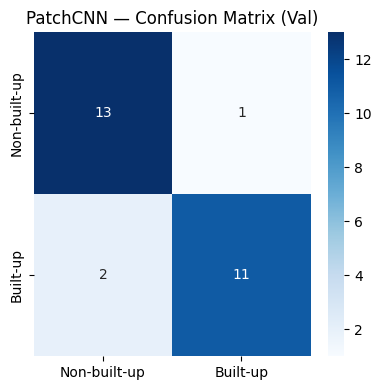

Saved: models/patchcnn_checkpoint.pth


In [21]:
cnn_model.load_state_dict(torch.load('models/patchcnn_best.pth', map_location=device))
cnn_model.eval()

all_p, all_t = [], []
with torch.no_grad():
    for x, y in cnn_val_loader:
        all_p.extend(torch.argmax(cnn_model(x.to(device)), 1).cpu().numpy())
        all_t.extend(y.numpy())

print(classification_report(all_t, all_p, target_names=['Non-built-up', 'Built-up']))

cm = confusion_matrix(all_t, all_p)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-built-up', 'Built-up'],
            yticklabels=['Non-built-up', 'Built-up'], cmap='Blues')
plt.title('PatchCNN — Confusion Matrix (Val)'); plt.tight_layout(); plt.show()

torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'in_channels': train_imgs.shape[1],
    'class_names': ['Non-built-up', 'Built-up'],
    'best_val_acc': best_cnn_acc,
}, 'models/patchcnn_checkpoint.pth')
print('Saved: models/patchcnn_checkpoint.pth')

---
## Part C — Mask R-CNN: Building Instance Segmentation
**Fixes**: no `[:3]` cap on instances, proper train/val split, evaluated on val set.

In [22]:
import cv2

# Use all patches (train + val) for Mask R-CNN — 3-band RGB input
all_patch_imgs = np.concatenate([train_imgs[:, :3], val_imgs[:, :3]], axis=0)
all_patch_msks = np.concatenate([train_msks,        val_msks],        axis=0)

instance_images = []
instance_masks  = []

for img, msk in zip(all_patch_imgs, all_patch_msks):
    bld = (msk == BUILDINGS).astype(np.uint8)
    if bld.sum() < 50:
        continue
    n_labs, labels = cv2.connectedComponents(bld)
    # FIX 6 — no [:3] cap, keep ALL instances
    inst_masks = [(labels == lab).astype(np.uint8)
                  for lab in range(1, n_labs)
                  if (labels == lab).sum() > 30]
    if len(inst_masks) == 0:
        continue
    instance_images.append(img)
    instance_masks.append(np.stack(inst_masks))

# Shuffle before split
idx_shuffle = np.random.permutation(len(instance_images))
instance_images = [instance_images[i] for i in idx_shuffle]
instance_masks  = [instance_masks[i]  for i in idx_shuffle]

print(f'Total patches with building instances: {len(instance_images)}')
print(f'Instance counts sample: {[len(m) for m in instance_masks[:8]]}')

Total patches with building instances: 278
Instance counts sample: [3, 3, 11, 9, 5, 13, 12, 6]


In [23]:
class BuildingInstanceDataset(Dataset):
    def __init__(self, imgs, masks):
        self.imgs  = imgs
        self.masks = masks

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        image = torch.tensor(self.imgs[idx], dtype=torch.float32)
        masks = torch.tensor(self.masks[idx], dtype=torch.uint8)
        boxes = []
        valid_masks = []
        for i in range(masks.shape[0]):
            pos = masks[i].nonzero()
            if len(pos) == 0:
                continue
            ymin, ymax = pos[:, 0].min().item(), pos[:, 0].max().item()
            xmin, xmax = pos[:, 1].min().item(), pos[:, 1].max().item()
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
                valid_masks.append(masks[i])
        if len(boxes) == 0:
            # Fallback: dummy entry so collate doesn't crash
            boxes = [[0, 0, 1, 1]]
            valid_masks = [torch.zeros(masks.shape[1:], dtype=torch.uint8)]
        valid_masks = torch.stack(valid_masks)
        target = {
            'boxes' : torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.ones(len(boxes), dtype=torch.int64),
            'masks' : valid_masks,
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [24]:
# FIX 5 — Proper train/val split for Mask R-CNN
n_inst       = len(instance_images)
n_train_inst = int(0.80 * n_inst)

inst_ds_train = BuildingInstanceDataset(instance_images[:n_train_inst],
                                         instance_masks[:n_train_inst])
inst_ds_val   = BuildingInstanceDataset(instance_images[n_train_inst:],
                                         instance_masks[n_train_inst:])

inst_train_loader = DataLoader(inst_ds_train, batch_size=2, shuffle=True,
                                collate_fn=collate_fn, num_workers=0)
inst_val_loader   = DataLoader(inst_ds_val,   batch_size=2, shuffle=False,
                                collate_fn=collate_fn, num_workers=0)

print(f'Instance train: {len(inst_ds_train)}  |  val: {len(inst_ds_val)}')

Instance train: 222  |  val: 56


In [25]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

maskrcnn = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)

in_feat = maskrcnn.roi_heads.box_predictor.cls_score.in_features
maskrcnn.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_feat, 2)

in_feat_mask = maskrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
maskrcnn.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, 2)

maskrcnn = maskrcnn.to(device)
print('Mask R-CNN ready')

Mask R-CNN ready


In [26]:
def box_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter  = max(0, xB - xA) * max(0, yB - yA)
    areaA  = (a[2]-a[0]) * (a[3]-a[1])
    areaB  = (b[2]-b[0]) * (b[3]-b[1])
    union  = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


# FIX 7 — LR scheduler
mrcnn_opt   = torch.optim.Adam(maskrcnn.parameters(), lr=1e-4)
mrcnn_sched = torch.optim.lr_scheduler.StepLR(mrcnn_opt, step_size=3, gamma=0.5)

EPOCHS_MRCNN   = 5   # increase to 10-15 on GPU
best_mrcnn_rec = 0.0

for epoch in range(EPOCHS_MRCNN):
    # TRAIN
    maskrcnn.train()
    t_loss = 0.0
    for imgs, targets in inst_train_loader:
        imgs    = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = maskrcnn(imgs, targets)
        loss = sum(loss_dict.values())
        mrcnn_opt.zero_grad(); loss.backward(); mrcnn_opt.step()
        t_loss += loss.item()
    mrcnn_sched.step()

    # FIX 5 — Evaluate on VAL loader, not train loader
    maskrcnn.eval()
    tp, total_gt = 0, 0
    with torch.no_grad():
        for imgs, targets in inst_val_loader:
            imgs    = [i.to(device) for i in imgs]
            outputs = maskrcnn(imgs)
            for out, tgt in zip(outputs, targets):
                gt_boxes   = tgt['boxes']
                pred_boxes = out['boxes']
                scores     = out['scores']
                # only confident predictions
                keep       = scores > 0.5
                pred_boxes = pred_boxes[keep]
                total_gt  += len(gt_boxes)
                matched    = set()
                for pb in pred_boxes:
                    for i, gb in enumerate(gt_boxes):
                        if i in matched: continue
                        if box_iou(pb.cpu().numpy(), gb.numpy()) >= 0.5:
                            tp += 1; matched.add(i); break

    recall = 100 * tp / total_gt if total_gt > 0 else 0
    if recall > best_mrcnn_rec:
        best_mrcnn_rec = recall
        torch.save(maskrcnn.state_dict(), 'models/maskrcnn_buildings_best.pth')

    print(f'Epoch {epoch+1:2d}/{EPOCHS_MRCNN} | '
          f'Train Loss: {t_loss/len(inst_train_loader):.4f} | '
          f'Val Recall@IoU0.5: {recall:.2f}%')

print(f'\nBest val recall: {best_mrcnn_rec:.2f}%  saved -> models/maskrcnn_buildings_best.pth')

Epoch  1/5 | Train Loss: 1.7148 | Val Recall@IoU0.5: 65.20%
Epoch  2/5 | Train Loss: 1.3989 | Val Recall@IoU0.5: 81.21%
Epoch  3/5 | Train Loss: 1.1248 | Val Recall@IoU0.5: 82.83%
Epoch  4/5 | Train Loss: 0.7843 | Val Recall@IoU0.5: 87.94%
Epoch  5/5 | Train Loss: 0.6139 | Val Recall@IoU0.5: 87.70%

Best val recall: 87.94%  saved -> models/maskrcnn_buildings_best.pth


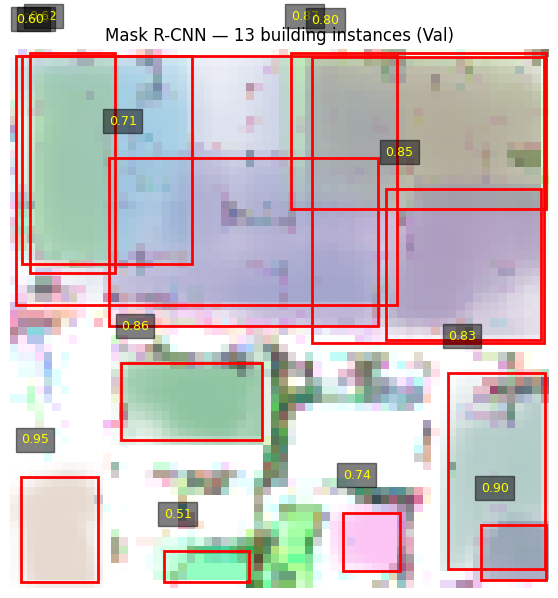

Saved: models/maskrcnn_checkpoint.pth


In [27]:
maskrcnn.load_state_dict(torch.load('models/maskrcnn_buildings_best.pth', map_location=device))
maskrcnn.eval()

def visualize_mrcnn(model, dataset, device, idx=0, score_thresh=0.5):
    img, _ = dataset[idx]
    with torch.no_grad():
        out = model([img.to(device)])[0]
    rgb = np.clip(img.permute(1, 2, 0).numpy() * 3.0, 0, 1)
    plt.figure(figsize=(7, 7)); plt.imshow(rgb); ax = plt.gca()
    det_count = 0
    for box, score, msk in zip(out['boxes'].cpu(), out['scores'].cpu(), out['masks'].cpu()):
        if score < score_thresh: continue
        x1, y1, x2, y2 = box.numpy()
        ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                                    fill=False, edgecolor='red', lw=2))
        overlay         = np.zeros((*msk[0].shape, 4))
        color           = np.random.rand(3)
        overlay[..., :3] = color
        overlay[..., 3]  = msk[0].numpy() * 0.45
        ax.imshow(overlay)
        ax.text(x1, y1-4, f'{score:.2f}', color='yellow', fontsize=9,
                bbox=dict(facecolor='black', alpha=0.5))
        det_count += 1
    plt.title(f'Mask R-CNN — {det_count} building instances (Val)')
    plt.axis('off'); plt.show()

visualize_mrcnn(maskrcnn, inst_ds_val, device, idx=0, score_thresh=0.5)

torch.save({
    'model_state_dict': maskrcnn.state_dict(),
    'num_classes': 2,
    'in_channels': 3,
    'best_val_recall': best_mrcnn_rec,
}, 'models/maskrcnn_checkpoint.pth')
print('Saved: models/maskrcnn_checkpoint.pth')

## Summary — Saved model files

| File | Contents |
|------|----------|
| `models/unet_vashi_best.pth` | U-Net weights (best val loss epoch) |
| `models/unet_vashi_checkpoint.pth` | U-Net weights + norm_stats + metadata |
| `models/unet_vashi_segmap.tif` | Full-image segmentation GeoTIFF |
| `models/patchcnn_best.pth` | PatchCNN weights (best val acc epoch) |
| `models/patchcnn_checkpoint.pth` | PatchCNN weights + metadata |
| `models/maskrcnn_buildings_best.pth` | Mask R-CNN weights (best val recall epoch) |
| `models/maskrcnn_checkpoint.pth` | Mask R-CNN weights + metadata |

All `.pth` checkpoint files contain `norm_stats` where applicable so the UI can normalize any new input image consistently.

In [ ]:
# ======================================================================
#  FINAL OUTPUT MAP - Vashi Sentinel-2 Segmentation Illustration
# ======================================================================
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb

CLASS_NAMES      = ["Background","Water","Buildings","Roads","Vegetation","Open Ground","Other Land"]
CLASS_COLORS_HEX = ["#000000",  "#00BFFF","#FF4444","#808080","#228B22","#FFD700","#FFA500"]

def pct_stretch(arr, lo=2, hi=98):
    v = arr[arr > 0]
    if v.size == 0: v = arr.ravel()
    a, b = np.percentile(v, lo), np.percentile(v, hi)
    return np.clip((arr - a) / max(b - a, 1e-6), 0, 1)

with rasterio.open("models/unet_vashi_segmap.tif") as s:
    seg = s.read(1).astype(np.uint8)

with rasterio.open("data/images/Vashi_Sentinel2_Input.tif") as s:
    bands = s.read().astype(np.float32)

C   = bands.shape[0]
rgb = np.stack([pct_stretch(bands[min(2,C-1)]),
                pct_stretch(bands[min(1,C-1)]),
                pct_stretch(bands[0])], axis=2)

cmap_c  = [to_rgb(c) for c in CLASS_COLORS_HEX]
seg_rgb = np.array([cmap_c[p] for p in seg.ravel()]).reshape(*seg.shape, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor="#0a0e17")
for ax, img, t in zip(axes,
        [rgb, seg_rgb, rgb*0.5+seg_rgb*0.5],
        ["Original (Sentinel-2 RGB)", "Segmentation Output", "Overlay (50% blend)"]):
    ax.imshow(img)
    ax.set_title(t, color="white", fontsize=12, fontweight="bold")
    ax.axis("off")

patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS_HEX, CLASS_NAMES)]
fig.legend(handles=patches, loc="lower center", ncol=7, fontsize=9,
           framealpha=0.2, facecolor="#0a0e17", edgecolor="#1e4976",
           labelcolor="white", bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Urban Feature Extraction - Vashi Sentinel-2 (U-Net 7-class)",
             color="#38bdf8", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("models/vashi_segmentation_illustration.png", dpi=150,
            bbox_inches="tight", facecolor="#0a0e17")
plt.show()
print("Saved: models/vashi_segmentation_illustration.png")

print("
-- Class Distribution --")
for i, name in enumerate(CLASS_NAMES):
    cnt = int(np.sum(seg == i))
    pct = 100 * cnt / seg.size
    print("  {:<15s} {:>9,} px  ({:.2f}%)".format(name, cnt, pct))
